In [73]:
import numpy as np
import pandas
import matplotlib.pyplot as plt

import scipy.stats

In [74]:
import sys
import requests
import importlib

def import_local_or_github(package_name, function_name=None, directory=None, giturl=None):
    # Import functions directly from github
    # Important: note that we use raw.githubusercontent.com, not github.com

    try: # to find the file locally
        if directory is not None:
            if directory not in sys.path:
                sys.path.append(directory)

        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

    except: # get the file from github
        if giturl is None:
            giturl = 'https://raw.githubusercontent.com/florisvb/Nonlinear_and_Data_Driven_Estimation/main/Utility/' + str(package_name) + '.py'

        r = requests.get(giturl)
        print('Fetching from: ')
        print(r)

        # Store the file to the colab working directory
        with open(package_name+'.py', 'w') as f:
            f.write(r.text)
        f.close()

        # import the function we want from that file
        package = importlib.import_module(package_name)
        if function_name is not None:
            function = getattr(package, function_name)
            return function
        else:
            return package

# planar_drone = import_local_or_github('planar_drone', directory='../Utility')
plot_tme = import_local_or_github('plot_utility', 'plot_tme', directory='../Utility')

# Load the data

And format it so the shapes and organization of the data matches standard mathematical notation.

### Load the arrays for the kalman filter

Colab tip: You may need to download them to your machine from notebook A, and then upload them to the colab environment where you are running this notebook.

In [75]:
# read from disk
loaded_arrays = np.load('ABCDRQ.npz')
A = loaded_arrays['A']
B = loaded_arrays['B']
C = loaded_arrays['C']
D = loaded_arrays['D']
R = loaded_arrays['R']
Q = loaded_arrays['Q']
# Q = np.diag(np.zeros(7)) # Make Q 7x7 # This line caused Q to be singular
Q = np.eye(7) * 1e-5 # Initialize Q as a small diagonal matrix

In [76]:
print('A shape: ', A.shape)
print('B shape: ', B.shape)
print('C shape: ', C.shape)
print('D shape: ', D.shape)
print('R shape: ', R.shape)
print('Q shape: ', Q.shape)

A shape:  (7, 7)
B shape:  (7, 2)
C shape:  (4, 7)
D shape:  (4, 2)
R shape:  (4, 4)
Q shape:  (7, 7)


### Load the state data and reorganize Y and U

Standard mathematical notation requires that each column of $Y$ correspond to the measurements at discrete time, i.e. $\mathbf{y}_k$, and each row of $\mathbf{y}$ correspond to each individual measurement. Similarly for $U$.

In [77]:
# read from disk
df_states = pandas.read_hdf('planar_drone_states.hdf')
df_measurements_true = pandas.read_hdf('planar_drone_measurements.hdf')
df_measurements_noisy = pandas.read_hdf('planar_drone_measurements_noisy.hdf')

In [78]:
Y = np.vstack(df_measurements_noisy[['theta', 'x', 'z', 'k']].values).T
print(Y.shape)

(4, 200)


In [79]:
U = np.vstack(df_states[['j1', 'j2']].values).T
print(U.shape)

(2, 200)


### Tip: When you index Y or U, make sure you are keeping a column vector.

In [80]:
# This is wrong
y_0 = Y[:, 0]
print(y_0)

[0.1101324  2.13160063 0.60006696 1.01104152]


In [81]:
# This is right
y_0 = Y[:, [0]]
print(y_0)

[[0.1101324 ]
 [2.13160063]
 [0.60006696]
 [1.01104152]]


## Tip: matrix multiplication in python

Recall that matrix shape during multiplication works like:

$[N\times M][M\times 1]=[N\times 1]$

In [82]:
# Option 1 using arrays
print('R shape: ', R.shape)
print('y_0 shape: ', y_0.shape)
print('[R x y_0] shape', (R@y_0).shape)
print('')
print('[R x y_0] = ')
R@y_0

R shape:  (4, 4)
y_0 shape:  (4, 1)
[R x y_0] shape (4, 1)

[R x y_0] = 


array([[0.00110132],
       [0.08526403],
       [0.09601071],
       [0.0001011 ]])

In [83]:
# Option 2 using matrices -- NOTE: np.matrix is getting deprecated, sadly, so this is not recommended
R_times_y_0 = np.matrix(R)*np.matrix(y_0)
print('[R x y_0] = ')
R_times_y_0

[R x y_0] = 


matrix([[0.00110132],
        [0.08526403],
        [0.09601071],
        [0.0001011 ]])

In [84]:
# Initialize state and covariance
x_hat = np.zeros((7, Y.shape[1]))  # State estimate (7x1)
P = np.zeros((7, 7, Y.shape[1]))   # Error covariance (7x7)

# Choose initial state and covariance
x_hat[:, [0]] = np.zeros((7, 1)) # Initial state estimate
P[:, :, 0] = np.eye(7) * 1000    # Initial error covariance (large uncertainty)

# Kalman Filter implementation
for k in range(1, Y.shape[1]):
    # Prediction step
    x_hat_minus = A @ x_hat[:, [k-1]] + B @ U[:, [k-1]]
    P_minus = A @ P[:, :, k-1] @ A.T + Q

    # Update step
    y_k = Y[:, [k]] - (C @ x_hat_minus + D @ U[:, [k]]) # Measurement residual
    S = C @ P_minus @ C.T + R                         # Measurement residual covariance
    K = P_minus @ C.T @ np.linalg.inv(S)              # Kalman gain

    x_hat[:, [k]] = x_hat_minus + K @ y_k             # Updated state estimate
    P[:, :, k] = (np.eye(7) - K @ C) @ P_minus         # Updated error covariance

# Exercises:

1. Code a linear discrete Kalman filter that uses the matrices and time series data defined above:
    * $A, B, C, D, R, Q$ matrices defined above
    * Measurements are given by $Y$
    * Controls are given by $U$
    * Choose an initial $\mathbf{x_0}$ and $P_0$
    * Try a larger value of Q, and a smaller value of Q. For this problem, does a larger or smaller value of Q lead to more accurate estimates? Why do you think that is?

2. Compare the error covariance of your Kalman filter to the Cramer Rao Bound. Is your KF efficient? Try for different values of Q.

3. Compare the error covariance of your KF and the CRB to the actual errors in your estimate. Does the distribution of the errors match that predicted by the error covariance and the CRB? Hint: the error covariance and the CRB report variance, the square of the standard deviation.

In [85]:
# x_hat_0 = np.zeros((7, 1)) # initial guess, doesn't matter too much what this is
# P_0 = np.eye(7) * 10

# for k in range(1, Y.shape[1]):
#     # propagate
#     x_hat_minus = A @ x_hat[:, [k-1]] + B @ U[:, [k-1]]
#     P_minus = A @ P[:, :, k-1] @ A.T + Q

#     # update step
#     y_k = Y[:, [k]] - (C @ x_hat_minus + D @ U[:, [k]])
#     S = C @ P_minus @ C.T + R
#     K = P_minus @ C.T @ np.linalg.inv(S)

#     x_hat[:, [k]] = x_hat_minus + K @ y_k
#     P[:, :, k] = (np.eye(7) - K @ C) @ P_minus

In [86]:
def linear_discrete_kalman_forward_update(xhat_fp, P_fp, y, u,
                                          A, B, C, D,
                                          R, Q):
  I = np.array(np.eye(A.shape[0]))

  # predict
  xhat_fm = A@xhat_fp + B@u
  P_fm = A@P_fp@A.T + Q

  # update
  K_f = P_fm@C.T@np.linalg.inv(C@P_fm@C.T + R)
  yhat = C@xhat_fm + D@u
  innovation = (y - yhat)
  xhat_fp = xhat_fm + K_f@innovation
  P_fp = (I - K_f@C)@P_fm

  return xhat_fp, P_fp

In [87]:
def linear_discrete_kalman_filter(x0, P0, Y, U,
                                  A, B, C, D,
                                  R, Q):
  xhat_fp = x0
  P_fp = [P0] # list, so we can keep adding to it

  lkf = linear_discrete_kalman_forward_update

  for i in range(Y.shape[1]):
    xhat_fp_i, P_fp_i = lkf(xhat_fp[:, [-1]], P_fp[-1],
                            Y[:, [i]], U[:, [i]],
                            A, B, C, D, R, Q)
    xhat_fp = np.hstack((xhat_fp, xhat_fp_i))
    P_fp.append(P_fp_i)

  return xhat_fp[:, 1:], P_fp[1:]

In [89]:
x0 = np.atleast_2d([1]*A.shape[0]).T # need column
P0 = np.eye(A.shape[0])*100 # initial covariance matrix

In [104]:
Q = 1e-4*np.eye(A.shape[0]).T

In [105]:
xhat_fp, P_fp = linear_discrete_kalman_filter(x0, P0, Y, U,
                                              A, B, C, D,
                                              R, Q)


In [106]:
xhat_fp.shape

(7, 200)

<Axes: xlabel='Time', ylabel='x'>

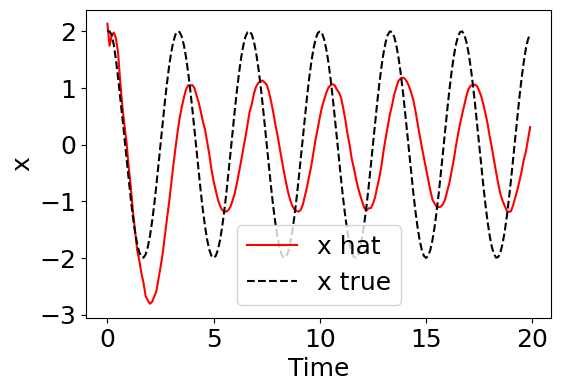

In [107]:
plot_tme(df_states.t, df_states['x'], None, xhat_fp[2,:], label_var='x')

In [108]:
Jk = np.linalg.inv(P0)
# Qinv = np.linalg.inv(Q)
Rinv = np.linalg.inv(R)

Js = [Jk]
for i in range(len(xhat_fp[1])):
  Jk = Js[-1]
  Jk1 = np.linalg.inv(Q) - np.linalg.inv(Q)@A@np.linalg.inv(Jk + A.T@np.linalg.inv(Q)@A)@A.T@np.linalg.inv(Q) + C.T@Rinv@C
  Js.append(Jk1)

In [109]:
Pdiags = np.vstack([np.diag(P_fp[i]) for i in range(len(P_fp))]).T

In [110]:
Pdiags.shape

(7, 200)

In [112]:
Jdiags = np.vstack([np.diag(np.linalg.inv(Js[i])) for i in range(1,len(Js))]).T

In [113]:
Jdiags.shape

(7, 200)

In [114]:
state_of_interest = 2

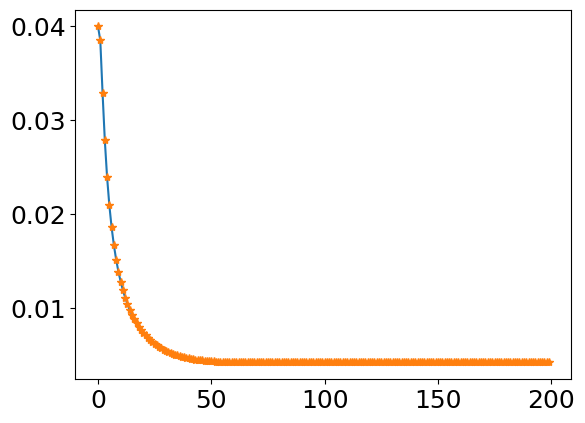

In [115]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(Pdiags[state_of_interest, :])
ax.plot(Jdiags[state_of_interest, :], '*')

In [116]:
errors = xhat_fp[state_of_interest, :] - df_states['x']

sigma = Pdiags[state_of_interest, :]**0.5

three_sigma = 3*sigma

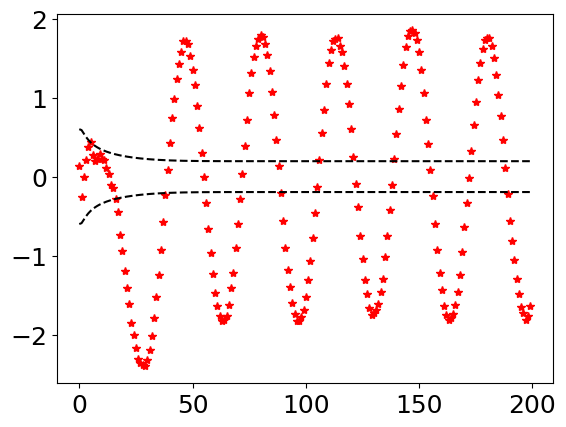

In [117]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(errors, '*', color='red')
ax.plot(three_sigma, '--', color='black')
ax.plot(-three_sigma, '--', color='black')

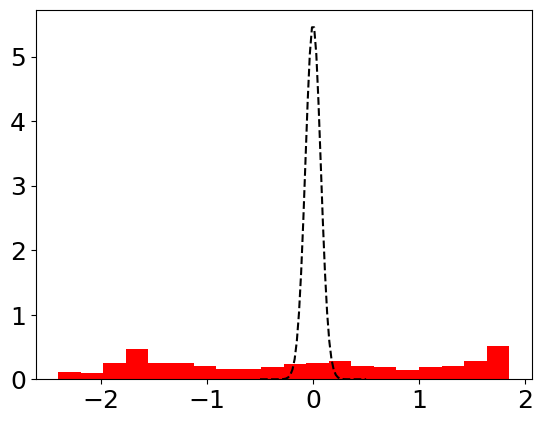

In [118]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.hist(errors, bins=20, color='red', density=True)

mean_sigma = np.mean(sigma)
gauss = scipy.stats.norm(0, mean_sigma)
xaxis = np.linspace(-0.5, 0.5, 50)
yaxis = gauss.pdf(xaxis)
ax.plot(xaxis, yaxis, '--', color='black')